# 🏥 Predição de Obesidade — Seleção e Treinamento de Modelo
**Objetivo:** Desenvolver um modelo de Machine Learning que auxilie médicos  
a prever o nível de obesidade de um paciente com base em seus hábitos e características físicas.

---
## 📦 Seção 1 — Importação das Bibliotecas

> **O que são bibliotecas?**  
> São conjuntos de funções prontas que outras pessoas desenvolveram e disponibilizaram.  
> Em vez de escrever tudo do zero, importamos essas ferramentas e as usamos.

| Biblioteca | Para que serve |
|---|---|
| `pandas` | Manipulação de tabelas de dados (o "Excel" do Python) |
| `numpy` | Operações matemáticas com arrays e matrizes |
| `matplotlib` / `seaborn` | Criação de gráficos e visualizações |
| `sklearn` | A principal biblioteca de Machine Learning do Python |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — dividida em módulos por funcionalidade
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Os 5 modelos que vamos comparar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Ferramentas para medir a qualidade do modelo
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')  # Oculta avisos técnicos desnecessários

print("✅ Todas as bibliotecas importadas com sucesso!")


✅ Todas as bibliotecas importadas com sucesso!


---
## 📥 Seção 2 — Carregamento dos Dados

> **Por que usar URL do GitHub?**  
> Ao ler o arquivo diretamente da URL raw do repositório, o notebook funciona  
> em qualquer computador com internet — sem precisar baixar o CSV manualmente.  
>
> A URL **raw** é diferente da URL da página do GitHub:  
> - ❌ Página GitHub: `github.com/usuario/repo/blob/main/arquivo.csv`  
> - ✅ URL raw (para leitura direta): `raw.githubusercontent.com/usuario/repo/main/arquivo.csv`


In [2]:
URL_DADOS = (
    "https://raw.githubusercontent.com/jnssena/tech_challenge_4"
    "/main/Referencias_Atividade/Obesity.csv"
)

df = pd.read_csv(URL_DADOS)

print(f"✅ Dados carregados!")
print(f"   Linhas (pacientes): {df.shape[0]}")
print(f"   Colunas (features): {df.shape[1]}")
df.head()


✅ Dados carregados!
   Linhas (pacientes): 2111
   Colunas (features): 17


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


---
## 🔍 Seção 3 — Análise Exploratória dos Dados (EDA)

> **O que é EDA?**  
> Antes de treinar qualquer modelo, precisamos *conhecer* os dados.  
> A EDA responde perguntas como:  
> - Quantos registros e colunas temos?  
> - Há valores faltando?  
> - As classes estão equilibradas?  
> - Quais variáveis são numéricas e quais são categóricas?  
>
> Sem essa etapa, podemos treinar um modelo em dados com problemas e não perceber.

### 3.1 — Visão geral da estrutura


In [3]:
# .info() mostra: tipos de dados, quantidade de valores não-nulos e uso de memória
# É a primeira coisa a rodar quando recebe um dataset novo
print("📋 Estrutura do Dataset:")
df.info()


📋 Estrutura do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float6

### 3.2 — Verificação de valores nulos

> **Por que checar nulos?**  
> A maioria dos algoritmos de ML **não aceita valores faltantes**.  
> Se existirem, precisamos tratá-los (preencher ou remover) antes de treinar.


In [4]:
nulos = df.isnull().sum()

if nulos.sum() == 0:
    print("✅ Nenhum valor nulo encontrado! O dataset está completo.")
else:
    print("⚠️ Valores nulos encontrados:")
    print(nulos[nulos > 0])


✅ Nenhum valor nulo encontrado! O dataset está completo.


### 3.3 — Distribuição das classes (variável alvo)

> **Por que isso importa?**  
> Se tivermos 90% de pacientes normais e 10% obesos, o modelo pode "trapacear"  
> prevendo sempre "normal" e ainda ter 90% de acurácia — mas seria inútil clinicamente.  
> Classes equilibradas são ideais para um modelo justo.


🎯 Distribuição da variável alvo: 'Obesity'
Obesity
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Total de classes: 7


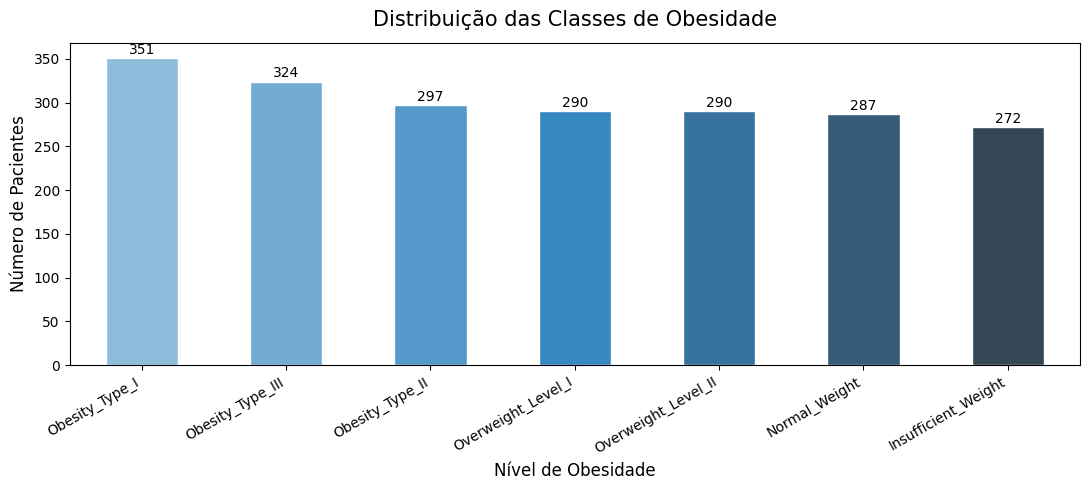

In [5]:
COLUNA_ALVO = 'Obesity'  # Coluna que queremos prever

print(f"🎯 Distribuição da variável alvo: '{COLUNA_ALVO}'")
contagem = df[COLUNA_ALVO].value_counts()
print(contagem)
print(f"\nTotal de classes: {df[COLUNA_ALVO].nunique()}")

# Gráfico de barras
fig, ax = plt.subplots(figsize=(11, 5))
cores = sns.color_palette("Blues_d", len(contagem))
contagem.plot(kind='bar', color=cores, edgecolor='white', ax=ax)
ax.set_title('Distribuição das Classes de Obesidade', fontsize=15, pad=12)
ax.set_xlabel('Nível de Obesidade', fontsize=12)
ax.set_ylabel('Número de Pacientes', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')

# Adiciona os valores em cima de cada barra
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            int(bar.get_height()),
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()


### 3.4 — Estatísticas descritivas das variáveis numéricas

> **O que cada métrica significa?**  
> - `mean` (média): valor central  
> - `std` (desvio padrão): o quanto os valores variam em torno da média  
> - `min` / `max`: valores extremos  
> - `25%`, `50%`, `75%`: quartis — dividem os dados em 4 partes iguais


In [6]:
print("📊 Estatísticas descritivas das variáveis NUMÉRICAS:")
df.describe().round(2).T  # .T transpõe a tabela (fica mais legível)


📊 Estatísticas descritivas das variáveis NUMÉRICAS:


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.31,6.35,14.00,19.95,22.78,26.00,61.00
Height,2111.0,1.70,0.09,1.45,1.63,1.70,1.77,1.98
Weight,2111.0,86.59,26.19,39.00,65.47,83.00,107.43,173.00
FCVC,2111.0,2.42,0.53,1.00,2.00,2.39,3.00,3.00
NCP,2111.0,2.69,0.78,1.00,2.66,3.00,3.00,4.00
CH2O,2111.0,2.01,0.61,1.00,1.58,2.00,2.48,3.00
FAF,2111.0,1.01,0.85,0.00,0.12,1.00,1.67,3.00
TUE,2111.0,0.66,0.61,0.00,0.00,0.63,1.00,2.00


### 3.5 — Correlação entre variáveis numéricas

> **O que é correlação?**  
> Mede o quanto duas variáveis "andam juntas":  
> - Correlação **+1**: sobem juntas (ex: peso e altura tendem a correlacionar)  
> - Correlação **-1**: uma sobe, outra desce  
> - Correlação **~0**: sem relação linear  
>
> Variáveis muito correlacionadas entre si podem ser redundantes para o modelo.


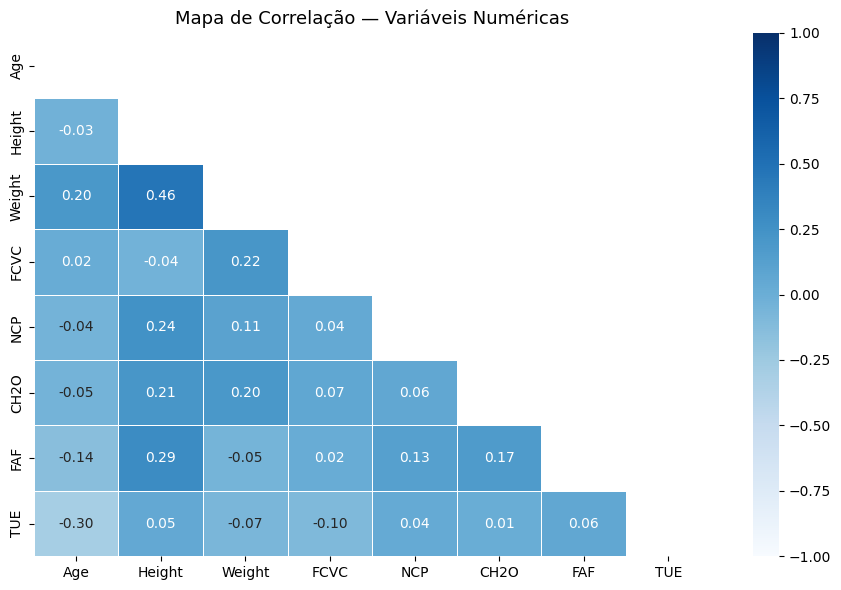

In [7]:
colunas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

plt.figure(figsize=(9, 6))
corr = df[colunas_numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # Oculta a metade espelhada
sns.heatmap(corr, mask=mask, cmap='Blues', annot=True, fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Mapa de Correlação — Variáveis Numéricas', fontsize=13)
plt.tight_layout()
plt.show()


---
## ⚙️ Seção 4 — Pré-processamento dos Dados

> Os algoritmos de Machine Learning trabalham **apenas com números**.  
> Nesta etapa transformamos os dados brutos no formato que os modelos esperam.

### Por que precisamos pré-processar?

| Problema | Solução aplicada |
|---|---|
| Colunas de texto (`Male`, `Female`, `yes`, `no`...) | **Label Encoding** — converte texto em número |
| Variáveis numéricas em escalas muito diferentes (peso vs. altura) | **StandardScaler** — padroniza tudo na mesma escala (dentro do Pipeline) |

### 4.1 — Label Encoding das variáveis categóricas

> **Como funciona o Label Encoding?**  
> Ele atribui um número inteiro para cada categoria única:  
> Ex: `Female → 0`, `Male → 1` | `no → 0`, `yes → 1`  
>
> ⚠️ **Atenção:** Para o target (coluna que queremos prever), também precisamos  
> fazer encoding — e guardar o encoder para depois converter os números de volta  
> em nomes legíveis nos resultados.


In [8]:
df_modelo = df.copy()  # Nunca modifique o dataframe original — trabalhe numa cópia

# Identificar colunas de texto (categóricas)
colunas_categoricas = df_modelo.select_dtypes(include='object').columns.tolist()
colunas_features_cat = [c for c in colunas_categoricas if c != COLUNA_ALVO]

print(f"Colunas categóricas (features): {colunas_features_cat}")
print(f"Coluna alvo: '{COLUNA_ALVO}'")

# Dicionário para guardar todos os encoders (precisaremos deles na predição)
encoders = {}

# Encoding das features categóricas
for col in colunas_features_cat:
    le = LabelEncoder()
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    encoders[col] = le  # Guarda o encoder desta coluna

# Encoding separado do target — guardamos para converter os resultados depois
le_target = LabelEncoder()
df_modelo[COLUNA_ALVO] = le_target.fit_transform(df_modelo[COLUNA_ALVO].astype(str))
encoders[COLUNA_ALVO] = le_target

print("\n✅ Encoding concluído!")
print(f"\nClasses do target (números → nomes):")
for i, classe in enumerate(le_target.classes_):
    print(f"  {i} → {classe}")


Colunas categóricas (features): ['Gender', 'family_history', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Coluna alvo: 'Obesity'

✅ Encoding concluído!

Classes do target (números → nomes):
  0 → Insufficient_Weight
  1 → Normal_Weight
  2 → Obesity_Type_I
  3 → Obesity_Type_II
  4 → Obesity_Type_III
  5 → Overweight_Level_I
  6 → Overweight_Level_II


### 4.2 — Separação em Features (X) e Target (y)

> **Conceito fundamental em ML:**  
> - **X (features):** as variáveis de entrada — o que o modelo *recebe*  
>   Ex: idade, peso, altura, hábitos alimentares...  
> - **y (target):** a variável de saída — o que o modelo *aprende a prever*  
>   Ex: o nível de obesidade


In [9]:
X = df_modelo.drop(columns=[COLUNA_ALVO])  # Tudo exceto a coluna alvo
y = df_modelo[COLUNA_ALVO]                 # Só a coluna alvo

print(f"X (entrada do modelo): {X.shape[1]} features, {X.shape[0]} amostras")
print(f"y (saída do modelo)  : {y.nunique()} classes")
print(f"\nFeatures utilizadas:")
for col in X.columns:
    print(f"  • {col}")


X (entrada do modelo): 16 features, 2111 amostras
y (saída do modelo)  : 7 classes

Features utilizadas:
  • Gender
  • Age
  • Height
  • Weight
  • family_history
  • FAVC
  • FCVC
  • NCP
  • CAEC
  • SMOKE
  • CH2O
  • SCC
  • FAF
  • TUE
  • CALC
  • MTRANS


### 4.3 — Divisão em Treino e Teste

> **Por que dividir?**  
> Imagine estudar para uma prova com as mesmas questões que cairão na avaliação —  
> você tiraria 10, mas não aprendeu de verdade. Com ML é igual:  
>
> - **Conjunto de treino (80%):** o modelo *aprende* com esses dados  
> - **Conjunto de teste (20%):** o modelo é *avaliado* com dados que nunca viu  
>
> O parâmetro `stratify=y` garante que a proporção de cada classe  
> seja preservada nos dois conjuntos — fundamental em dados médicos.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para teste
    random_state=42,     # Semente aleatória — garante reproducibilidade
    stratify=y           # Mantém proporção das classes em treino e teste
)

print(f"Treino : {X_train.shape[0]} pacientes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste  : {X_test.shape[0]} pacientes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n✅ Divisão concluída com stratify — proporções preservadas!")


Treino : 1688 pacientes (80%)
Teste  : 423 pacientes (20%)

✅ Divisão concluída com stratify — proporções preservadas!


---
## 🤖 Seção 5 — Definição e Comparação dos Modelos

### Por que testar vários modelos?

Não existe um algoritmo universalmente melhor para todos os problemas.  
Cada modelo tem suposições e pontos fortes diferentes:

| Modelo | Como funciona (resumo simples) | Ponto forte |
|---|---|---|
| **Regressão Logística** | Encontra uma fronteira linear entre as classes | Rápido, interpretável |
| **Árvore de Decisão** | Cria perguntas do tipo "se/então" em sequência | Muito fácil de entender |
| **Random Forest** | Combina centenas de árvores e vota no resultado | Robusto, bom por padrão |
| **Gradient Boosting** | Treina árvores sequencialmente, corrigindo erros | Alta precisão |
| **KNN** | Olha os K pacientes mais parecidos e vota | Simples, intuitivo |

### O que é um Pipeline?

> Um `Pipeline` encadeia etapas de transformação + modelo em um único objeto.  
> Isso garante que o **StandardScaler** (normalização) seja ajustado *só no treino*  
> e aplicado corretamente no teste — evitando um erro chamado **data leakage**  
> (vazamento de informação do teste para o treino, que inflaciona os resultados).

### O que é Validação Cruzada (Cross-Validation)?

> Em vez de avaliar o modelo uma única vez, dividimos o conjunto de treino  
> em **5 partes (folds)**. O modelo treina 5 vezes, cada vez usando 4 partes  
> para treino e 1 para validação. A acurácia final é a **média das 5 rodadas**.  
> Isso dá uma estimativa muito mais confiável da qualidade real do modelo.


In [11]:
# Definição dos modelos — cada um dentro de um Pipeline com normalização
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),          # Passo 1: normaliza os dados
        ("modelo", LogisticRegression(         # Passo 2: treina o modelo
            max_iter=1000,
            random_state=42
        ))
    ]),
    "Árvore de Decisão": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", RandomForestClassifier(
            n_estimators=100,   # 100 árvores no ensemble
            random_state=42
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", GradientBoostingClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]),
    "KNN (K-Vizinhos)": Pipeline([
        ("scaler", StandardScaler()),          # KNN é MUITO sensível à escala
        ("modelo", KNeighborsClassifier(n_neighbors=5))
    ]),
}

# Validação cruzada estratificada (mantém proporção das classes em cada fold)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados = {}

print("⏳ Avaliando modelos com validação cruzada (5 folds)...\n")
for nome, pipeline in modelos.items():
    scores = cross_val_score(
        pipeline, X_train, y_train,
        cv=cv,
        scoring='accuracy'
    )
    resultados[nome] = {"media": scores.mean(), "std": scores.std(), "scores": scores}
    barra = "█" * int(scores.mean() * 30)
    print(f"  {nome:25s} → {scores.mean():.4f} ± {scores.std():.4f}  {barra}")

print("\n✅ Avaliação concluída!")


⏳ Avaliando modelos com validação cruzada (5 folds)...

  Regressão Logística       → 0.8679 ± 0.0179  ██████████████████████████
  Árvore de Decisão         → 0.9206 ± 0.0140  ███████████████████████████
  Random Forest             → 0.9467 ± 0.0115  ████████████████████████████
  Gradient Boosting         → 0.9656 ± 0.0081  ████████████████████████████
  KNN (K-Vizinhos)          → 0.7956 ± 0.0128  ███████████████████████

✅ Avaliação concluída!


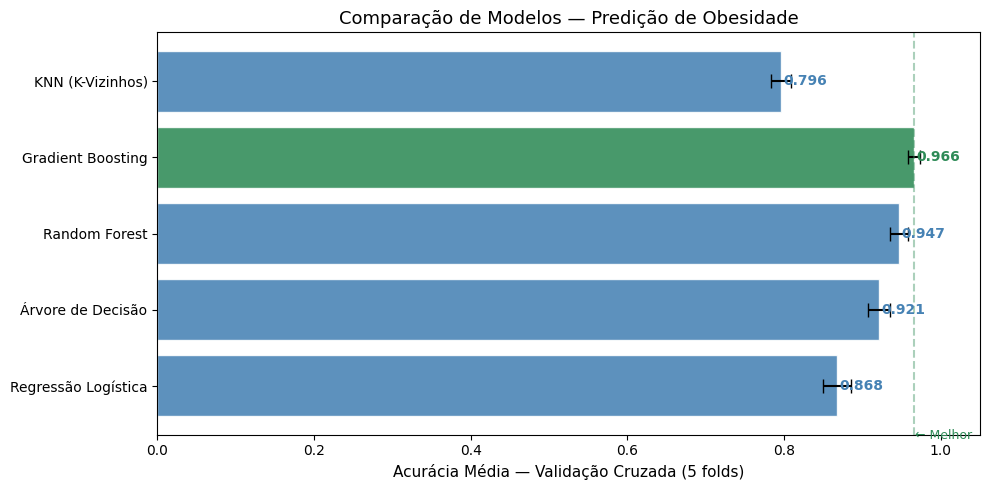

In [12]:
# ── Gráfico comparativo dos modelos
nomes   = list(resultados.keys())
medias  = [resultados[n]['media'] for n in nomes]
desvios = [resultados[n]['std']   for n in nomes]
melhor_idx = int(np.argmax(medias))

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['seagreen' if i == melhor_idx else 'steelblue' for i in range(len(nomes))]
bars = ax.barh(nomes, medias, xerr=desvios, color=cores,
               edgecolor='white', capsize=5, alpha=0.88)

# Anota o valor em cada barra
for i, (bar, media) in enumerate(zip(bars, medias)):
    ax.text(media + 0.003, bar.get_y() + bar.get_height()/2,
            f'{media:.3f}', va='center', fontsize=10,
            color='seagreen' if i == melhor_idx else 'steelblue', fontweight='bold')

ax.set_xlabel('Acurácia Média — Validação Cruzada (5 folds)', fontsize=11)
ax.set_title('Comparação de Modelos — Predição de Obesidade', fontsize=13)
ax.set_xlim(0, 1.05)
ax.axvline(x=max(medias), color='seagreen', linestyle='--', alpha=0.4)
ax.text(max(medias)+0.001, -0.7, '← Melhor', color='seagreen', fontsize=9)
plt.tight_layout()
plt.show()


---
## 🏆 Seção 6 — Treinamento e Avaliação do Melhor Modelo

> Agora que sabemos qual modelo se saiu melhor na validação cruzada,  
> o treinamos com **todo o conjunto de treino** e avaliamos no **conjunto de teste**  
> — dados que ele nunca viu em nenhum momento.

### Métricas de avaliação utilizadas

| Métrica | O que mede | Quando usar |
|---|---|---|
| **Acurácia** | % de previsões corretas no total | Quando as classes são equilibradas |
| **F1-Score** | Equilíbrio entre precisão e recall | Mais justo com classes desbalanceadas |
| **Matriz de Confusão** | Onde o modelo erra e acerta por classe | Diagnóstico detalhado dos erros |


In [13]:
# Seleciona automaticamente o melhor modelo pela maior acurácia média
nome_melhor = max(resultados, key=lambda n: resultados[n]['media'])
modelo_final = modelos[nome_melhor]

print(f"🏆 Melhor modelo: {nome_melhor}")
print(f"   Acurácia na validação cruzada: {resultados[nome_melhor]['media']:.4f} "
      f"(± {resultados[nome_melhor]['std']:.4f})")

# Treina no conjunto completo de treino
modelo_final.fit(X_train, y_train)
print("\n✅ Modelo treinado com sucesso!")


🏆 Melhor modelo: Gradient Boosting
   Acurácia na validação cruzada: 0.9656 (± 0.0081)

✅ Modelo treinado com sucesso!


In [14]:
# Avaliação no conjunto de TESTE
y_pred = modelo_final.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("=" * 55)
print(f"  📊 RESULTADOS NO CONJUNTO DE TESTE — {nome_melhor}")
print("=" * 55)
print(f"  Acurácia  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.1f}%)")
print("=" * 55)

# Relatório por classe — mostra precisão/recall de cada nível de obesidade
print("\n📋 Relatório detalhado por classe:")
print(classification_report(
    y_test, y_pred,
    target_names=le_target.classes_  # Converte números de volta para nomes
))


  📊 RESULTADOS NO CONJUNTO DE TESTE — Gradient Boosting
  Acurácia  : 0.9598  (96.0%)
  F1-Score  : 0.9603  (96.0%)

📋 Relatório detalhado por classe:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.91      0.95        54
      Normal_Weight       0.85      0.98      0.91        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.97      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.93      0.91      0.92        58
Overweight_Level_II       1.00      0.98      0.99        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



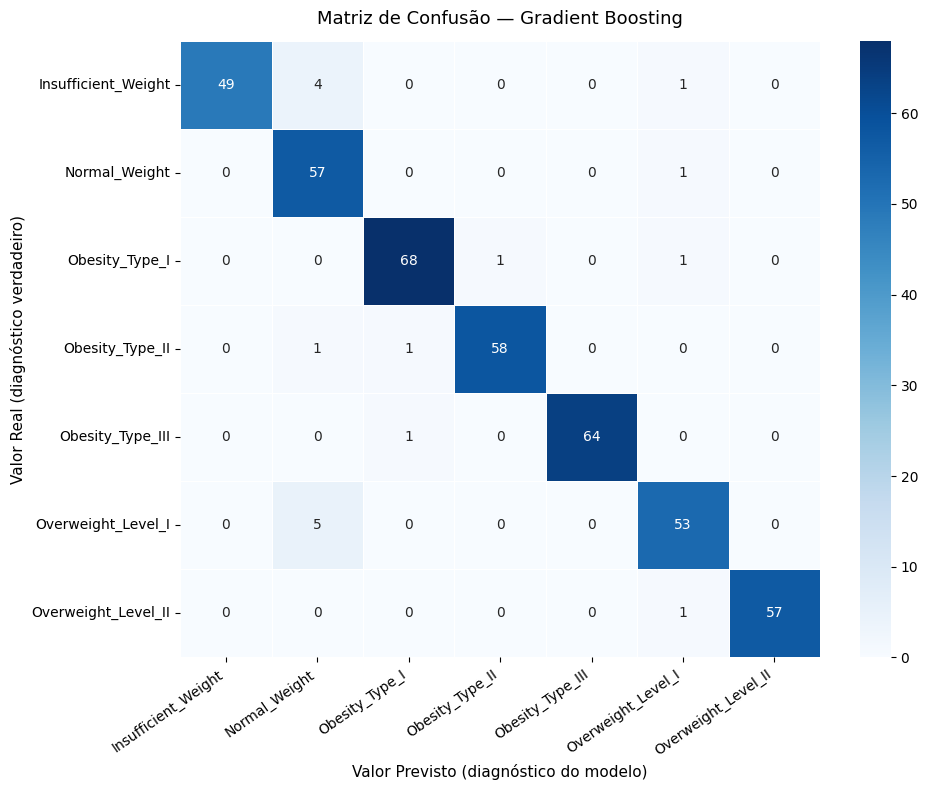


💡 Como ler a Matriz de Confusão:
   • Diagonal principal (↘): acertos — modelo previu corretamente
   • Fora da diagonal    : erros  — modelo confundiu uma classe com outra


In [15]:
# ── Matriz de Confusão
fig, ax = plt.subplots(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_,
    linewidths=0.5,
    ax=ax
)
ax.set_title(f'Matriz de Confusão — {nome_melhor}', fontsize=13, pad=12)
ax.set_ylabel('Valor Real (diagnóstico verdadeiro)', fontsize=11)
ax.set_xlabel('Valor Previsto (diagnóstico do modelo)', fontsize=11)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n💡 Como ler a Matriz de Confusão:")
print("   • Diagonal principal (↘): acertos — modelo previu corretamente")
print("   • Fora da diagonal    : erros  — modelo confundiu uma classe com outra")


---
## 📊 Seção 7 — Importância das Features

> **Por que isso é valioso clinicamente?**  
> Além da previsão, o modelo pode nos dizer *quais fatores mais influenciam*  
> o nível de obesidade. Isso ajuda a equipe médica a focar nos aspectos  
> mais relevantes durante a consulta.


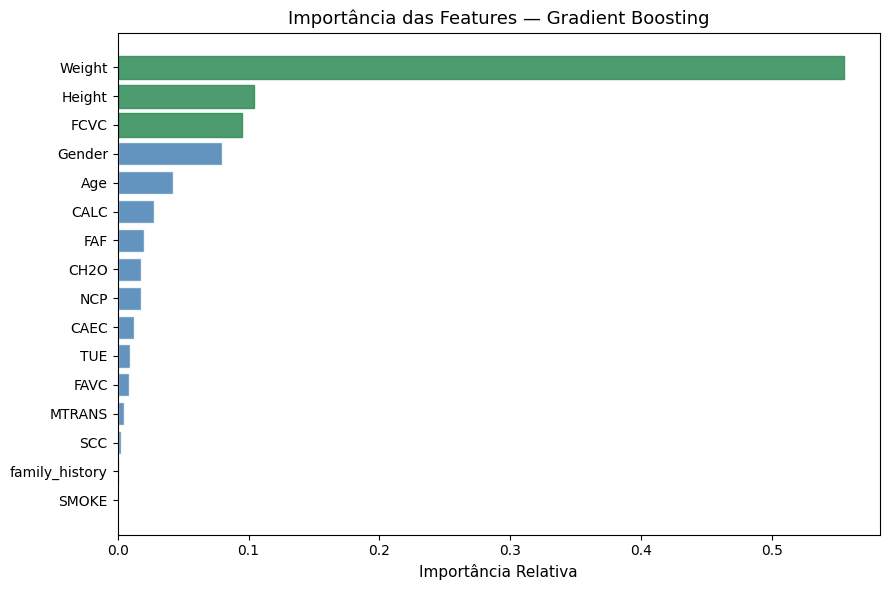

🔑 Top 5 fatores mais determinantes para o diagnóstico:
  • Weight                         0.5545
  • Height                         0.1043
  • FCVC                           0.0949
  • Gender                         0.0797
  • Age                            0.0420


In [16]:
estimador = modelo_final.named_steps['modelo']

if hasattr(estimador, 'feature_importances_'):
    importancias = estimador.feature_importances_
    feat_df = pd.DataFrame({
        'Feature': X.columns,
        'Importância': importancias
    }).sort_values('Importância', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(feat_df['Feature'], feat_df['Importância'],
                   color='steelblue', edgecolor='white', alpha=0.85)

    # Destaca o top 3
    for i, bar in enumerate(bars):
        if i >= len(bars) - 3:
            bar.set_color('seagreen')

    ax.set_xlabel('Importância Relativa', fontsize=11)
    ax.set_title(f'Importância das Features — {nome_melhor}', fontsize=13)
    plt.tight_layout()
    plt.show()

    print("🔑 Top 5 fatores mais determinantes para o diagnóstico:")
    top5 = feat_df.tail(5).iloc[::-1]
    for _, row in top5.iterrows():
        print(f"  • {row['Feature']:30s} {row['Importância']:.4f}")

elif hasattr(estimador, 'coef_'):
    # Regressão Logística usa coeficientes ao invés de importâncias
    coefs = np.abs(estimador.coef_).mean(axis=0)
    feat_df = pd.DataFrame({
        'Feature': X.columns,
        'Importância': coefs
    }).sort_values('Importância', ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(feat_df['Feature'], feat_df['Importância'],
            color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Coeficiente médio (valor absoluto)', fontsize=11)
    ax.set_title(f'Importância das Features — {nome_melhor}', fontsize=13)
    plt.tight_layout()
    plt.show()


---
## 🩺 Seção 8 — Sistema Preditivo (Simulação de Diagnóstico)

> Aqui simulamos o uso real do modelo:  
> a equipe médica insere os dados de um novo paciente  
> e recebe o diagnóstico preditivo com o nível de obesidade  
> e as probabilidades de cada classe.

### Dicionário das variáveis (preencha corretamente)

| Coluna | Tipo | Valores possíveis |
|---|---|---|
| `Gender` | texto | `'Male'` ou `'Female'` |
| `Age` | número | ex: `25.0` |
| `Height` | número (metros) | ex: `1.75` |
| `Weight` | número (kg) | ex: `80.0` |
| `family_history` | texto | `'yes'` ou `'no'` |
| `FAVC` | texto (consome calórico freq.) | `'yes'` ou `'no'` |
| `FCVC` | número (freq. vegetais 1–3) | ex: `2.0` |
| `NCP` | número (refeições/dia) | ex: `3.0` |
| `CAEC` | texto (come entre refeições) | `'no'`, `'Sometimes'`, `'Frequently'`, `'Always'` |
| `SMOKE` | texto | `'yes'` ou `'no'` |
| `CH2O` | número (litros água/dia 1–3) | ex: `2.0` |
| `SCC` | texto (monitora calorias) | `'yes'` ou `'no'` |
| `FAF` | número (freq. atividade física 0–3) | ex: `1.0` |
| `TUE` | número (horas em tela 0–2) | ex: `1.0` |
| `CALC` | texto (freq. álcool) | `'no'`, `'Sometimes'`, `'Frequently'`, `'Always'` |
| `MTRANS` | texto (transporte) | `'Public_Transportation'`, `'Walking'`, `'Automobile'`, `'Motorbike'`, `'Bike'` |


╔══════════════════════════════════════════════╗
║       🩺 RESULTADO DO DIAGNÓSTICO PREDITIVO  ║
╠══════════════════════════════════════════════╣
║  Diagnóstico previsto: Obesity_Type_I         ║
║  Confiança do modelo : 49.9%                    ║
╚══════════════════════════════════════════════╝

📊 Probabilidade por classe:
 Nível de Obesidade  Probabilidade (%)
     Obesity_Type_I               49.9
Overweight_Level_II               49.1
 Overweight_Level_I                0.5
      Normal_Weight                0.4
Insufficient_Weight                0.0
   Obesity_Type_III                0.0
    Obesity_Type_II                0.0


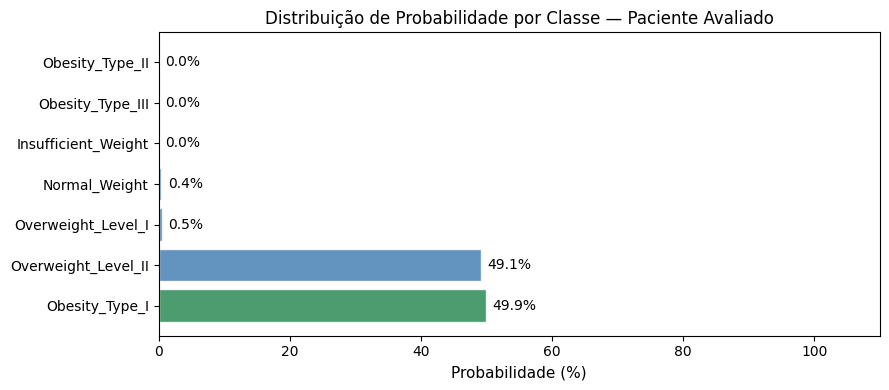

In [17]:
# ════════════════════════════════════════════════════════
# 👨‍⚕️ PREENCHA OS DADOS DO PACIENTE ABAIXO
# ════════════════════════════════════════════════════════

dados_paciente = {
    'Gender'          : 'Male',
    'Age'             : 30.0,
    'Height'          : 1.75,
    'Weight'          : 95.0,
    'family_history'  : 'yes',
    'FAVC'            : 'yes',   # Consome alimentos calóricos frequentemente?
    'FCVC'            : 2.0,     # Frequência de consumo de vegetais (1-3)
    'NCP'             : 3.0,     # Número de refeições principais por dia
    'CAEC'            : 'Sometimes',  # Come entre refeições?
    'SMOKE'           : 'no',
    'CH2O'            : 2.0,     # Litros de água por dia (1-3)
    'SCC'             : 'no',    # Monitora calorias consumidas?
    'FAF'             : 1.0,     # Frequência de atividade física (0-3)
    'TUE'             : 1.0,     # Horas/dia em dispositivos (0-2)
    'CALC'            : 'Sometimes',  # Frequência de consumo de álcool
    'MTRANS'          : 'Public_Transportation'
}

# ════════════════════════════════════════════════════════
# Processamento automático — não precisa alterar abaixo
# ════════════════════════════════════════════════════════

paciente_df = pd.DataFrame([dados_paciente])

# Aplica o mesmo encoding usado no treino
for col in colunas_features_cat:
    if col in paciente_df.columns:
        le_col = encoders[col]
        valor = paciente_df[col].astype(str)
        # Trata valores não vistos no treino (evita erro)
        valor_safe = valor.map(
            lambda v: v if v in le_col.classes_ else le_col.classes_[0]
        )
        paciente_df[col] = le_col.transform(valor_safe)

# Garante a mesma ordem de colunas do treino
paciente_df = paciente_df[X.columns]

# Predição
predicao_num = modelo_final.predict(paciente_df)[0]
predicao_nome = le_target.inverse_transform([predicao_num])[0]

# Probabilidades (se o modelo suportar)
probs = modelo_final.predict_proba(paciente_df)[0]
prob_df = pd.DataFrame({
    'Nível de Obesidade': le_target.classes_,
    'Probabilidade (%)' : (probs * 100).round(1)
}).sort_values('Probabilidade (%)', ascending=False)

# ── Resultado
print("╔══════════════════════════════════════════════╗")
print("║       🩺 RESULTADO DO DIAGNÓSTICO PREDITIVO  ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Diagnóstico previsto: {predicao_nome:<23}║")
print(f"║  Confiança do modelo : {probs.max()*100:.1f}%{' '*20}║")
print("╚══════════════════════════════════════════════╝")

print("\n📊 Probabilidade por classe:")
print(prob_df.to_string(index=False))

# Gráfico de probabilidades
fig, ax = plt.subplots(figsize=(9, 4))
cores_prob = ['seagreen' if c == predicao_nome else 'steelblue'
              for c in prob_df['Nível de Obesidade']]
bars = ax.barh(prob_df['Nível de Obesidade'], prob_df['Probabilidade (%)'],
               color=cores_prob, edgecolor='white', alpha=0.85)
ax.set_xlabel('Probabilidade (%)', fontsize=11)
ax.set_title('Distribuição de Probabilidade por Classe — Paciente Avaliado',
             fontsize=12)
ax.set_xlim(0, 110)
for bar, val in zip(bars, prob_df['Probabilidade (%)']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()


---
## 📚 Seção 9 — Resumo do Projeto e Próximos Passos

### O que foi feito neste notebook

| Etapa | Técnica | Por quê |
|---|---|---|
| Carregamento | `pd.read_csv(URL)` | Portabilidade — funciona em qualquer máquina |
| EDA | `.info()`, `.describe()`, correlação | Conhecer os dados antes de modelar |
| Pré-processamento | `LabelEncoder` + `Pipeline` | ML só aceita números; Pipeline evita data leakage |
| Divisão | `train_test_split` com `stratify` | Avaliar em dados nunca vistos, preservando proporções |
| Comparação | `cross_val_score` (5 folds) | Estimativa confiável — não depende de uma única divisão |
| Seleção | Automática pelo maior F1/Acurácia | Objetivo e reproduzível |
| Avaliação | Acurácia, F1, Matriz de Confusão | Visão completa dos acertos e erros |
| Sistema | Predição com probabilidades por classe | Uso clínico real |

### 🚀 Próximos passos sugeridos

1. **Otimizar hiperparâmetros** com `GridSearchCV` — testa combinações de parâmetros automaticamente  
2. **Salvar o modelo** com `joblib.dump(modelo_final, 'modelo_obesidade.pkl')` — reutilizar sem retreinar  
3. **Interface web** com `Streamlit` — criar um formulário visual para a equipe médica usar  
4. **Explorar outros algoritmos** como XGBoost ou LightGBM — geralmente superam o Gradient Boosting padrão  

---
### 📖 Referências e onde aprender mais

**Livros:**
- *Mãos à Obra: Aprendizado de Máquina* — Aurélien Géron (O'Reilly) — o mais recomendado para iniciantes em ML com sklearn  
- *Python para Análise de Dados* — Wes McKinney (O'Reilly) — criador do pandas; referência em EDA  
- *Introdução ao Aprendizado de Máquina* — Andreas Müller & Sarah Guido (O'Reilly)  

**Sites e cursos:**
- [scikit-learn.org/stable/user_guide](https://scikit-learn.org/stable/user_guide.html) — documentação oficial do sklearn (exemplos práticos em cada página)  
- [kaggle.com/learn](https://kaggle.com/learn) — cursos gratuitos de ML, pandas e visualização  
- [Alura](https://www.alura.com.br) — cursos em português de Data Science e ML  
- [fast.ai](https://fast.ai) — curso gratuito de Deep Learning (passo seguinte natural)  

**Conceitos para aprofundar (por ordem sugerida):**  
1. Bias-Variance Tradeoff  
2. Overfitting e Regularização  
3. GridSearchCV e otimização de hiperparâmetros  
4. Curva ROC e AUC  
5. Ensemble Methods (Bagging vs Boosting)
